# create masks for the problematic models that were not saved in zarr 2


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')


In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

/home/b/b382616/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33803 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/33803/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/33803/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44269,Workers: 32
Dashboard: /user/b382616/levante-spawner-advanced//proxy/33803/status,Total threads: 32
Started: Just now,Total memory: 250.00 GiB
Comm: tcp://127.0.0.1:43323,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/35811/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:41015,


2026-01-09 14:02:32,464 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,466 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,475 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,479 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,483 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,488 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,492 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,496 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,501 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,506 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,511 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,515 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,520 - distributed.nanny - WARNING - Restarting worker
2026-01-09 14:02:32,523 - distributed.

# LOAD DATA
#### the functions need datasets of SST anomalies with dimensions (time,lat,lon)
#### Only take latitudes between 50°S and 70°N, to retain only ice-free oceans. To make sure no sea ice appears in these latitudes we apply SSTA=SSTA.where(sst>-1.7) for all anomalies.
#### Gridcells with sea ice are defined in OSTIA,ICON and IFS-FESOM as an SST value of ~ -1.75, by applying the 'where' condition we make sure to only take ice free times and grid-cells without throwing out entire areas, but only the times and places where sea ice appears.
#### Also, convert ICON and IFS-FESOM longitudes from 0->360 to -180->180

In [3]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [4]:
#SST


# IFS NEMO
filename='/home/b/b382616/scratch/ifsnemo_hist_sst.zarr' 
sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})
sst_n=sst_n.tos.chunk({'time':150, 'lat':-1, 'lon':-1})
sst_n=sst_n.sel(lat=slice(-50, 70))
            


/tmp/ipykernel_1680286/956411223.py:6: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})


In [5]:



# IFS-NEMO ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
sst_n=lon_180w_180e(sst_n)
n_ds = n_ds.sel(lat=slice(-50, 70))
nssta=n_ds['dat_anomaly']
sst_n=sst_n.sel(time=slice((nssta.time[0].values),str(nssta.time[-1].values)))
# Now apply the sea ice mask
nssta = nssta.where(sst_n > -1.7)

# Regional masks
### region_masks.zarr is already in this folder and in the shapefile path, but you can create the mask following these steps:

Create regional masks based on SST variance relevance.

You have to download the oceanic regions from the shapefile at

Flanders Marine Institute (2021). Global Oceans and Seas, version 1. Available online at https://www.marineregions.org/. https://doi.org/10.14284/542.


Put this file in the same place as your shapefile_path. This file is then heavily modified to  adapt it to the wanted regions.

The 'create_model_specific_masks' function needs a one-time slice of global sst to work.

You have to provide an example_sst for the oceanic regions masks for each model to be created: Any single time slice of lat and lon will work.

if you don't specify it in the funbction then it's going to look for it in the same path where I saved my shapefile.

This is what I did:

In [28]:


##for NEMO EXAMPLE SST
# IFS-NEMO ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
sst_n=lon_180w_180e(sst_n)
n_ds = n_ds.sel(lat=slice(-50, 70))
nssta=n_ds['dat_anomaly']
nssta.isel(time=10).to_netcdf('/home/b/b382616/scratch/mhws/DV8/example_sst_NEMO.nc')






sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


In [22]:


# 1. Define your paths
shapefile_path = '/home/b/b382616/scratch/mhws/DV8/goas_v01.shp'
mask_save_dir = Path('/home/b/b382616/scratch/mhws/DV8/extremes_model_masks')
nemo_path = '/home/b/b382616/scratch/mhws/DV8/example_sst_NEMO.nc'

# 2. Load the data (the function expects a DataArray to extract grid info)
nemo_ds = xr.open_dataset(nemo_path)
# Use a tuple (dataset, variable_name) which the helper function understands
nemo_data = (nemo_ds, 'dat_anomaly') # Replace 'tos' with your actual SST variable name

# 3. Wrap in a dictionary as expected by create_model_specific_masks
models_dict = {'NEMO': nemo_data}

# 4. Run the function
masks_dict = create_model_specific_masks(
    models_dict=models_dict, 
    shapefile_path=shapefile_path, 
    mask_save_dir=mask_save_dir
)

Creating model-specific masks...
Creating masks for NEMO...
Creating masks from shapefile for model grid (481,) x (1440,)...
  Found model-specific example SST: /home/b/b382616/scratch/mhws/DV8/example_sst_NEMO.nc
  Using model-specific example SST for NEMO


ERROR 1: PROJ: internal_proj_create_from_database: /sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


  Creating Southern Ocean mask...
  Creating mask for North Pacific Ocean...
  Creating mask for South Pacific Ocean...
  Creating mask for North Atlantic Ocean...
  Creating mask for South Atlantic Ocean...
  Creating mask for Indian Ocean...
  Creating equatorial mask for Pacific...
  Creating equatorial mask for Atlantic...
  Creating equatorial mask for Indian...
  Creating mask for Mediterranean Region...
  Creating mask for Baltic Sea...
  Creating mask for South China and Easter Archipelagic Seas...
Applying region modifications...
  Creating Western and Eastern Equatorial Pacific masks...
    Western points: 31166, Eastern points: 22720, Total: 53886
Ensuring masks are mutually exclusive...
Total conflicts resolved: 4416
Model-specific masks saved to /home/b/b382616/scratch/mhws/DV8/extremes_model_masks/extremes_NEMO_481x1440_-2130404455801615551_region_masks.zarr
  NEMO grid: (481,) x (1440,)
  NEMO regions: ['Southern_Ocean', 'North_Pacific_SubTropics', 'North_Pacific_MiddleL

In [8]:

shapefile_path = '/home/b/b382616/scratch/mhws/DV8/goas_v01.shp'
mask_save_dir = Path('/home/b/b382616/scratch/mhws/DV8/extremes_model_masks')

hadgem_models = {
    'HadGEM3-LL': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_LL.nc',
    'HadGEM3-MM': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_MM.nc',
    'HadGEM3-HH': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_HH.nc'
}

for model_name, example_file in hadgem_models.items():
    print(f"Creating masks for {model_name}...")
    
    # Load the example SST
    ds = xr.open_dataset(example_file)
    
    # Extract the data array (assuming variable is named 'sst')
    if 'sst' in ds:
        data_array = ds['sst']
    else:
        # If not named 'sst', take the first data variable
        var_name = list(ds.data_vars)[0]
        data_array = ds[var_name]
    
    # Create masks
    masks = create_model_specific_shapefile_mask(
        data_array, 
        model_name=model_name, 
        shapefile_path=shapefile_path, 
        mask_save_dir=mask_save_dir
    )
    
    print(f"  Created {len(masks)} masks for {model_name}.")
    print(f"  Masks saved to: {mask_save_dir}")

Creating masks for HadGEM3-LL...


FileNotFoundError: [Errno 2] No such file or directory: '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_LL.nc'

### For hadgems it was more complicated....


Since hadgems was saved with version 3 of zarr, and this notebook was initially designed for version 2 (env name 'super'), when I cretated an environment ('super_trooper') with version 3 of zarr, the mask-making fucntions didn't work anymore.
so what I did was:

- on super_trooper: save example_sst files for the three hadgems models (as seen above among the others)
- on super, and in a different notebook: create the masks for hadgems with:


    Define paths
shapefile_path = '/home/b/b382616/scratch/mhws/DV8/goas_v01.shp'
mask_save_dir = Path('/home/b/b382616/scratch/mhws/DV8/extremes_model_masks')

      List of HadGEM models and their example SST files
hadgem_models = {
    'HadGEM3-LL': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_LL.nc',
    'HadGEM3-MM': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_MM.nc',
    'HadGEM3-HH': '/home/b/b382616/scratch/mhws/DV8/example_sst_HadGEM3_HH.nc'
}

for model_name, example_file in hadgem_models.items():
    print(f"Creating masks for {model_name}...")
    
    # Load the example SST
    ds = xr.open_dataset(example_file)
    
    # Extract the data array (assuming variable is named 'sst')
    if 'sst' in ds:
        data_array = ds['sst']
    else:
        # If not named 'sst', take the first data variable
        var_name = list(ds.data_vars)[0]
        data_array = ds[var_name]
    
    # Create masks
    masks = create_model_specific_shapefile_mask(
        data_array, 
        model_name=model_name, 
        shapefile_path=shapefile_path, 
        mask_save_dir=mask_save_dir
    )
    
    print(f"  Created {len(masks)} masks for {model_name}.")
    print(f"  Masks saved to: {mask_save_dir}")

- and then Here on super_trooper I load them all directly with:



mask_save_dir = Path('/scratch/b/b382616/mhws/DV8/extremes_model_masks')

      All model names
all_models = ['OSTIA', 'ICON', 'IFS-FESOM', 'HadGEM3-LL', 'HadGEM3-MM', 'HadGEM3-HH']

masks_dict = {}

for model in all_models:
    # Find the mask file for this model
    mask_files = list(mask_save_dir.glob(f'*{model}*.zarr'))
    
    if mask_files:
        mask_file = mask_files[0]
        print(f"Loading {model} mask from {mask_file.name}")
        
        mask_ds = xr.open_zarr(str(mask_file))
        
        # For HadGEM models, select latitude range
        if model.startswith('HadGEM3-'):
            mask_ds = mask_ds.sel(lat=slice(-50, 70))
            print(f"  Selected lat range -50 to 70")
        
        masks_dict[model] = mask_ds
        print(f"  ✓ Loaded {len(mask_ds.data_vars)} regions")
    else:
        print(f"Warning: No mask file found for {model}")

print(f"\nSuccessfully loaded masks for {len(masks_dict)} models")

#### Available regions:
                Southern_Ocean
                North_Pacific_SubTropics
                North_Pacific_MiddleLats
                South_Pacific_SubTropics
                North_Atlantic_SubTropics
                North_Atlantic_MiddleLats
                South_Atlantic_SubTropics
                Indian_SouthSubTropics
                Indian_NorthSubTropics
                Mediterranean_Sea

COMPUTING GLOBAL SEASONAL PDFS
(DIVIDED BY HEMISPHERE)

Processing season: DJF (months [12, 1, 2])
  OSTIA...


2025-11-19 16:29:28,558 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 5.99 GiB -- Worker memory limit: 7.36 GiB
2025-11-19 16:29:30,682 - distributed.worker.memory - WARNING - Worker is at 73% memory usage. Resuming worker. Process memory: 5.39 GiB -- Worker memory limit: 7.36 GiB
2025-11-19 16:29:30,684 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.39 GiB -- Worker memory limit: 7.36 GiB
2025-11-19 16:29:35,761 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:42187
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, f

    NH: 670,955,924 points, mean: 0.002
    SH: 723,339,552 points, mean: 0.000
  ICON...
    NH: 656,635,189 points, mean: 0.007
    SH: 721,452,134 points, mean: 0.000
  IFS-FESOM...
    NH: 662,679,370 points, mean: 0.003
    SH: 720,609,643 points, mean: -0.000

Processing season: MAM (months [3, 4, 5])
  OSTIA...


2025-11-19 16:34:49,271 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:44961
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/core.py", line 1018, in send_recv
    response = await comm.read(deserializers=deserializers)
  File "/home/b/b382616/.local/lib/python3.10/sit

    NH: 680,489,107 points, mean: 0.003
    SH: 737,675,136 points, mean: 0.000
  ICON...
    NH: 666,261,011 points, mean: 0.014
    SH: 735,750,312 points, mean: -0.000
  IFS-FESOM...
    NH: 670,818,848 points, mean: 0.005
    SH: 734,891,124 points, mean: 0.000

Processing season: JJA (months [6, 7, 8])
  OSTIA...


2025-11-19 16:41:26,510 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:45793
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/core.py", line 1018, in send_recv
    response = await comm.read(deserializers=deserializers)
  File "/home/b/b382616/.local/lib/python3.10/sit

    NH: 711,076,905 points, mean: 0.004
    SH: 737,675,136 points, mean: 0.000
  ICON...
    NH: 701,726,912 points, mean: 0.014
    SH: 735,750,312 points, mean: 0.000
  IFS-FESOM...
    NH: 698,192,120 points, mean: 0.001
    SH: 734,891,124 points, mean: -0.000

Processing season: SON (months [9, 10, 11])
  OSTIA...
    NH: 707,092,046 points, mean: 0.000
    SH: 729,656,928 points, mean: -0.000
  ICON...
    NH: 695,825,514 points, mean: 0.001
    SH: 727,753,026 points, mean: -0.000
  IFS-FESOM...
    NH: 689,928,713 points, mean: 0.001
    SH: 726,903,177 points, mean: 0.000

Plotting Northern Hemisphere...


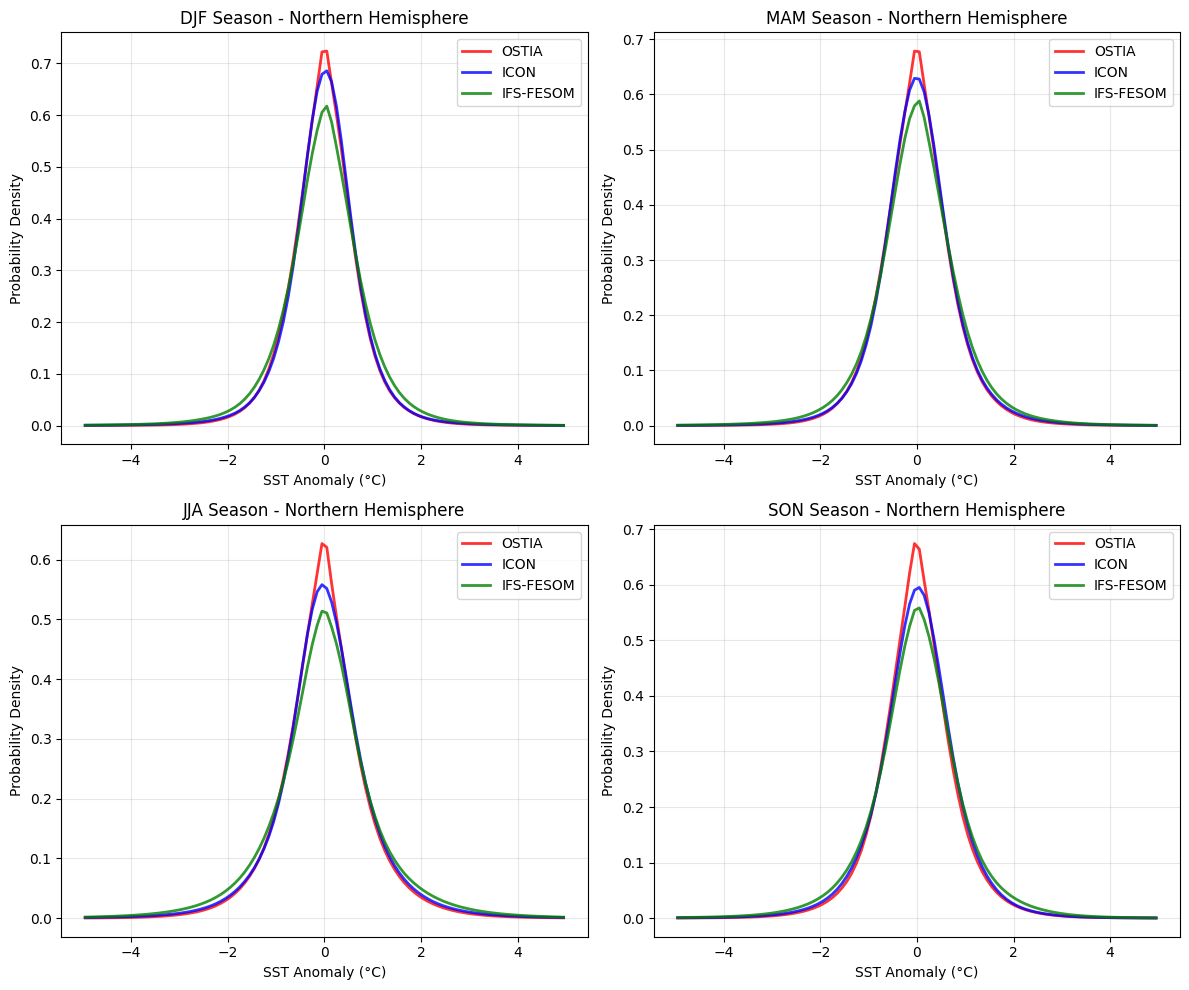


Plotting Southern Hemisphere...


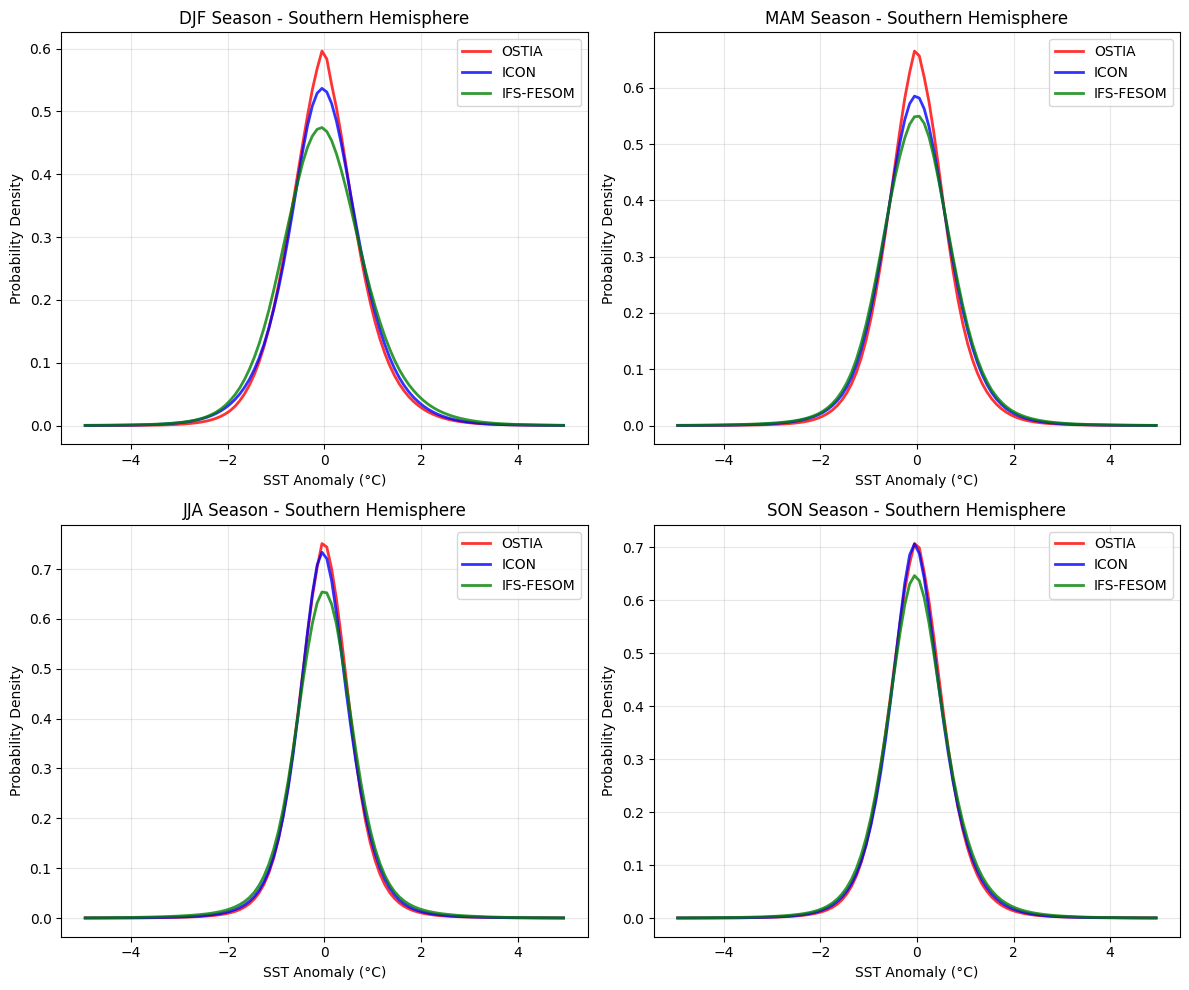


GLOBAL SEASONAL STATISTICS BY HEMISPHERE:

DJF Season:

  Northern Hemisphere:
  Model           |     Mean |      Std |  Data Points
  ------------------------------------------------------------
  OSTIA           |    0.002 |    0.726 |  670,955,924
  ICON            |    0.007 |    0.783 |  656,635,189
  IFS-FESOM       |    0.003 |    0.915 |  662,679,370

  Southern Hemisphere:
  Model           |     Mean |      Std |  Data Points
  ------------------------------------------------------------
  OSTIA           |    0.000 |    0.821 |  723,339,552
  ICON            |    0.000 |    0.886 |  721,452,134
  IFS-FESOM       |   -0.000 |    0.972 |  720,609,643

MAM Season:

  Northern Hemisphere:
  Model           |     Mean |      Std |  Data Points
  ------------------------------------------------------------
  OSTIA           |    0.003 |    0.776 |  680,489,107
  ICON            |    0.014 |    0.829 |  666,261,011
  IFS-FESOM       |    0.005 |    0.946 |  670,818,848

  Souther

In [6]:
# Your models dictionary
models_dict = {
    'OSTIA': (ossta),
    'ICON': (issta),
    'IFS-FESOM': (fssta),
}

# Global seasonal PDFs, divided by hemisphere
global_seasonal_pdfs = quick_global_seasonal_analysis(models_dict,by_hemisphere=True)


  Creating mask for South Atlantic Ocean...
  Creating mask for Indian Ocean...
  Creating equatorial mask for Pacific...
  Creating equatorial mask for Atlantic...
  Creating equatorial mask for Indian...
  Creating mask for Mediterranean Region...
  Creating mask for Baltic Sea...
  Creating mask for South China and Easter Archipelagic Seas...
Applying region modifications...
Ensuring masks are mutually exclusive...
Total conflicts resolved: 0
PDF-specific masks saved to /scratch/b/b382616/mhws/DV8/pdf_model_masks/pdf_model_480x1440_8809792844020250730_region_masks.zarr
  OSTIA grid: (480,) x (1440,)
  OSTIA regions: ['Southern_Ocean', 'North_Pacific_SubTropics', 'North_Pacific_MiddleLats', 'South_Pacific_SubTropics', 'North_Atlantic_SubTropics', 'North_Atlantic_MiddleLats', 'South_Atlantic_SubTropics', 'Indian_SouthSubTropics', 'Indian_NorthSubTropics', 'Pacific_Equatorial', 'Atlantic_Equatorial', 'Indian_Equatorial', 'Mediterranean_Sea']
Creating PDF masks for ICON...
Creating PDF-

2025-11-19 10:33:37,854 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:40791
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.lo

      166,092,784 points, mean: 0.000
    ICON...
      170,102,803 points, mean: 0.000
    IFS-FESOM...
      170,073,033 points, mean: -0.000
  Season: MAM
    OSTIA...


2025-11-19 10:36:33,138 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.51 GiB -- Worker memory limit: 7.36 GiB


      169,384,512 points, mean: -0.000
    ICON...
      173,474,004 points, mean: 0.000
    IFS-FESOM...
      173,443,644 points, mean: 0.000
  Season: JJA
    OSTIA...
      169,384,512 points, mean: 0.000
    ICON...
      173,474,004 points, mean: 0.000
    IFS-FESOM...
      173,443,644 points, mean: 0.000
  Season: SON
    OSTIA...
      167,543,376 points, mean: -0.000
    ICON...
      171,588,417 points, mean: -0.000
    IFS-FESOM...
      171,558,387 points, mean: 0.000

Processing region: North_Pacific_SubTropics
  Season: DJF
    OSTIA...


...

      24,780,756 points, mean: -0.000
    ICON...
      24,537,513 points, mean: -0.000
    IFS-FESOM...
      24,480,456 points, mean: 0.000

Processing region: Mediterranean_Sea
  Season: DJF
    OSTIA...


2025-11-19 12:27:54,481 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:38451
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.lo

      14,568,580 points, mean: 0.001
    ICON...
      14,661,725 points, mean: -0.000
    IFS-FESOM...
      14,414,634 points, mean: 0.001
  Season: MAM
    OSTIA...
      14,868,369 points, mean: 0.000
    ICON...
      14,952,300 points, mean: 0.000
    IFS-FESOM...
      14,700,312 points, mean: -0.000
  Season: JJA
    OSTIA...
      14,873,364 points, mean: 0.001
    ICON...
      14,952,300 points, mean: -0.000
    IFS-FESOM...
      14,700,312 points, mean: 0.001
  Season: SON
    OSTIA...


2025-11-19 12:37:23,417 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:38755
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.lo

      14,711,697 points, mean: 0.000
    ICON...
      14,789,775 points, mean: 0.000
    IFS-FESOM...
      14,540,526 points, mean: -0.001

Plotting seasonal PDFs for Southern_Ocean


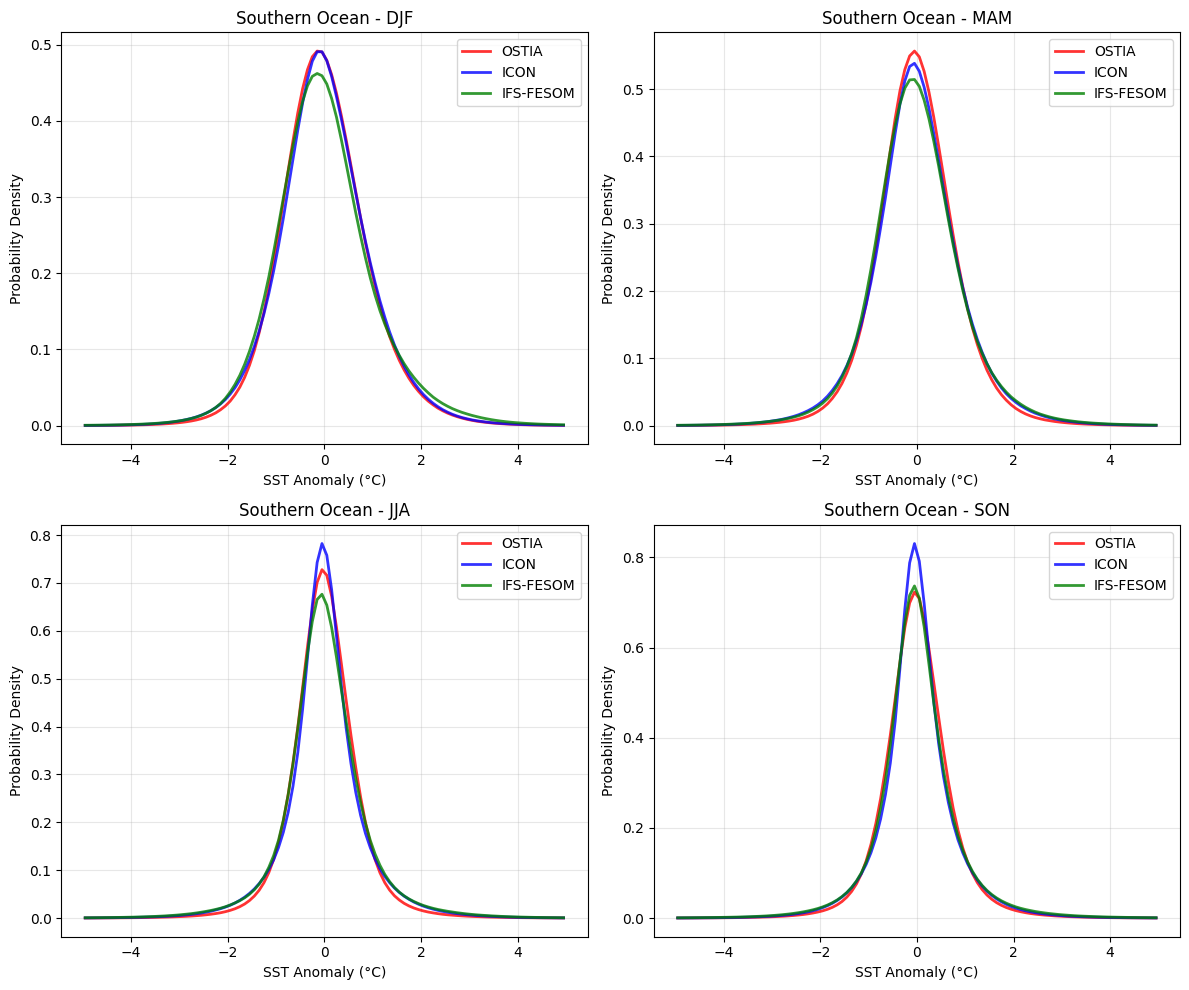


Southern Ocean - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.925 |  166,092,784
ICON            |    0.000 |    0.969 |  170,102,803
IFS-FESOM       |   -0.000 |    1.059 |  170,073,033

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.848 |  169,384,512
ICON            |    0.000 |    0.938 |  173,474,004
IFS-FESOM       |    0.000 |    0.970 |  173,443,644

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.725 |  169,384,512
ICON            |    0.000 |    0.827 |  173,474,004
IFS-FESOM       |    0.000 |    0.893 |  173,443,644

SON Season:
Model           |     Mean |      Std |  Data Points
-------------------------------------

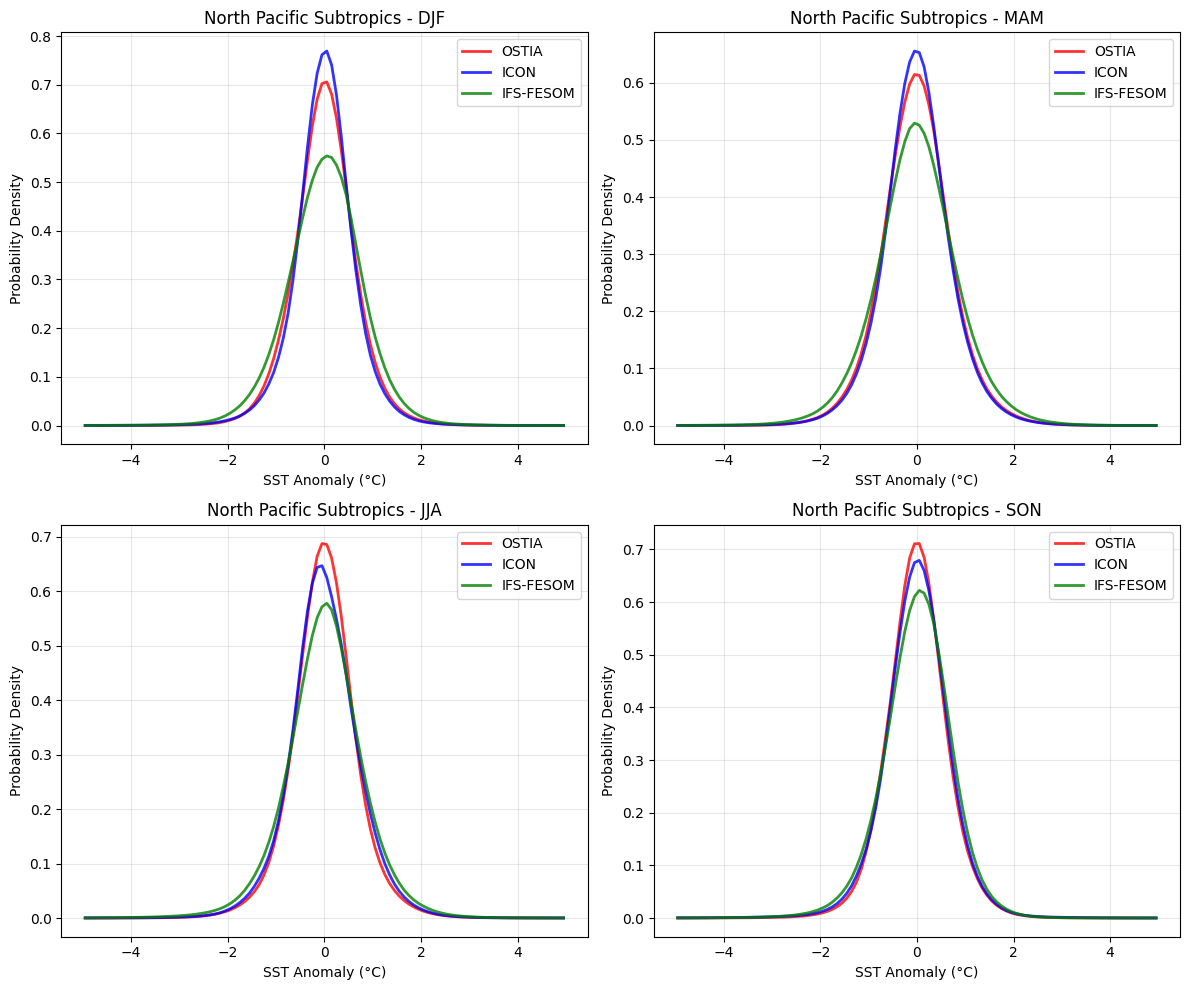


North Pacific Subtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.651 |  138,281,650
ICON            |   -0.000 |    0.635 |  137,713,043
IFS-FESOM       |   -0.000 |    0.795 |  137,641,595

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.730 |  141,022,200
ICON            |    0.000 |    0.721 |  140,442,324
IFS-FESOM       |   -0.000 |    0.867 |  140,369,460

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.676 |  141,022,200
ICON            |    0.000 |    0.722 |  140,442,324
IFS-FESOM       |    0.001 |    0.825 |  140,369,460

SON Season:
Model           |     Mean |      Std |  Data Points
---------------------------

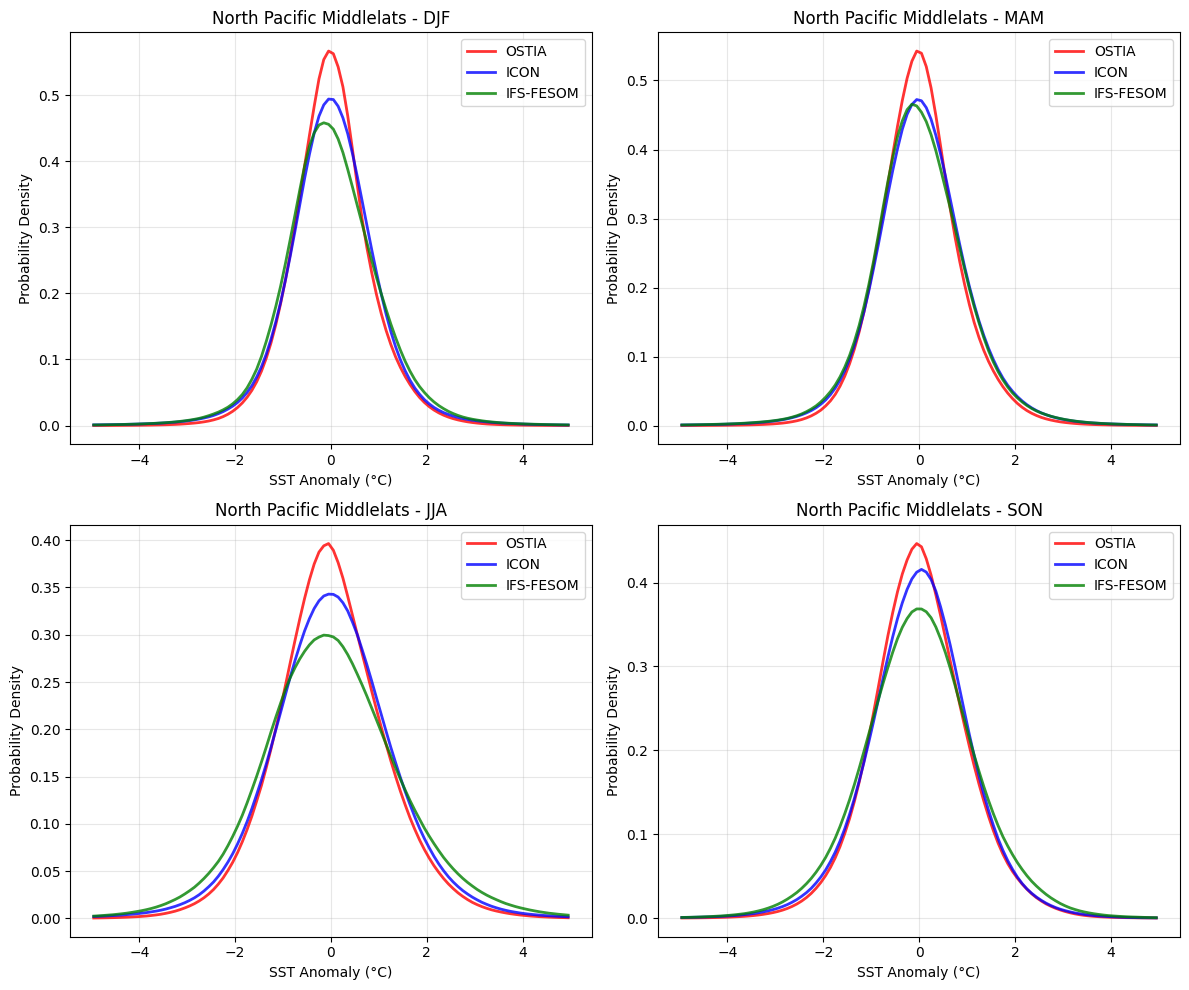


North Pacific Middlelats - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.004 |    0.841 |  139,949,490
ICON            |    0.016 |    0.999 |  131,361,225
IFS-FESOM       |    0.001 |    1.049 |  137,643,988

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.007 |    0.868 |  141,647,226
ICON            |    0.034 |    1.033 |  132,593,728
IFS-FESOM       |    0.003 |    1.046 |  139,633,861

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.001 |    1.161 |  149,042,268
ICON            |    0.012 |    1.330 |  147,541,219
IFS-FESOM       |   -0.000 |    1.505 |  147,466,638

SON Season:
Model           |     Mean |      Std |  Data Points
---------------------------

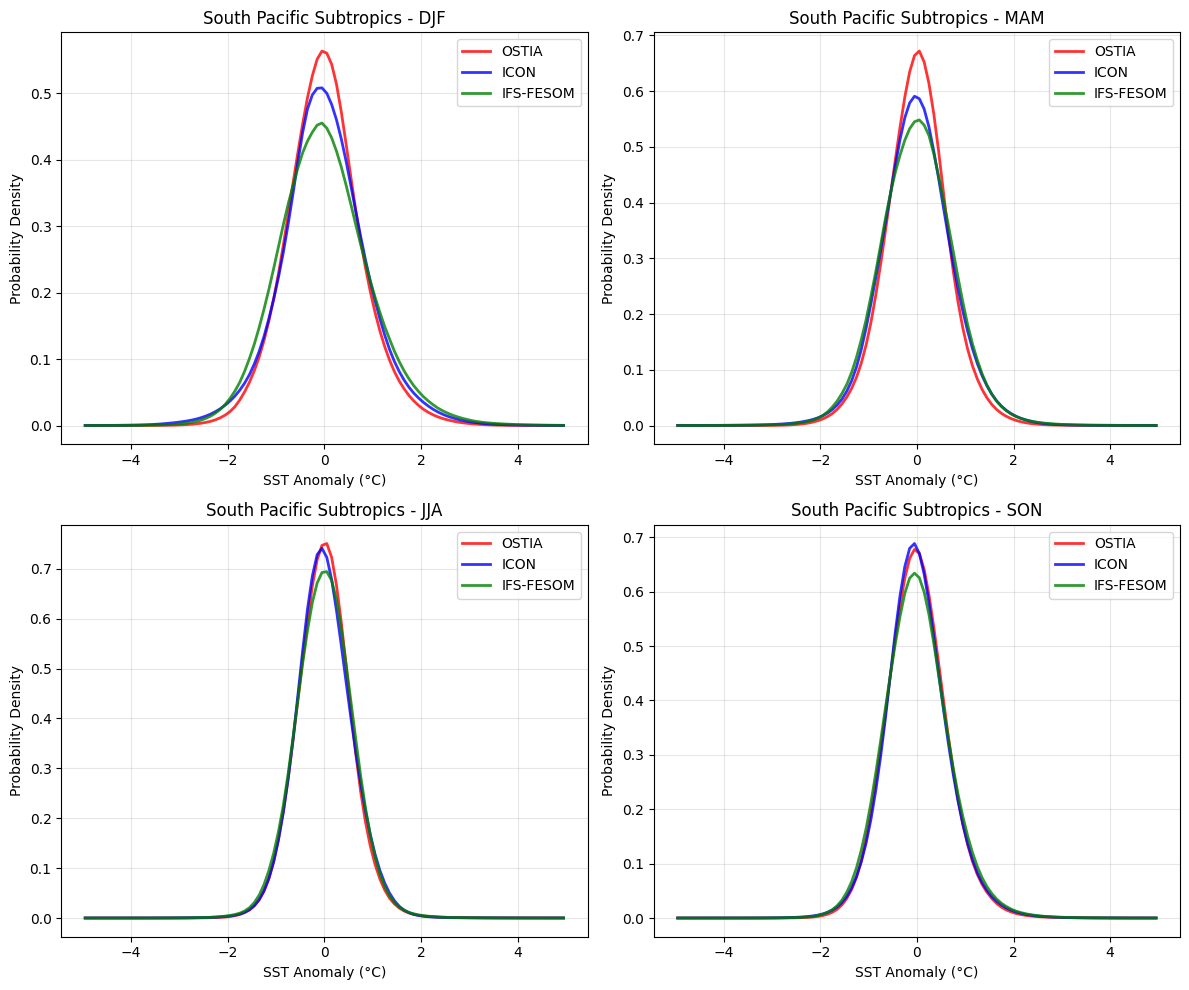


South Pacific Subtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.790 |  197,422,732
ICON            |   -0.000 |    0.904 |  195,347,763
IFS-FESOM       |   -0.000 |    0.960 |  195,329,901

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.657 |  201,335,376
ICON            |   -0.000 |    0.757 |  199,219,284
IFS-FESOM       |    0.000 |    0.767 |  199,201,068

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.570 |  201,335,376
ICON            |    0.000 |    0.580 |  199,219,284
IFS-FESOM       |   -0.000 |    0.598 |  199,201,068

SON Season:
Model           |     Mean |      Std |  Data Points
---------------------------

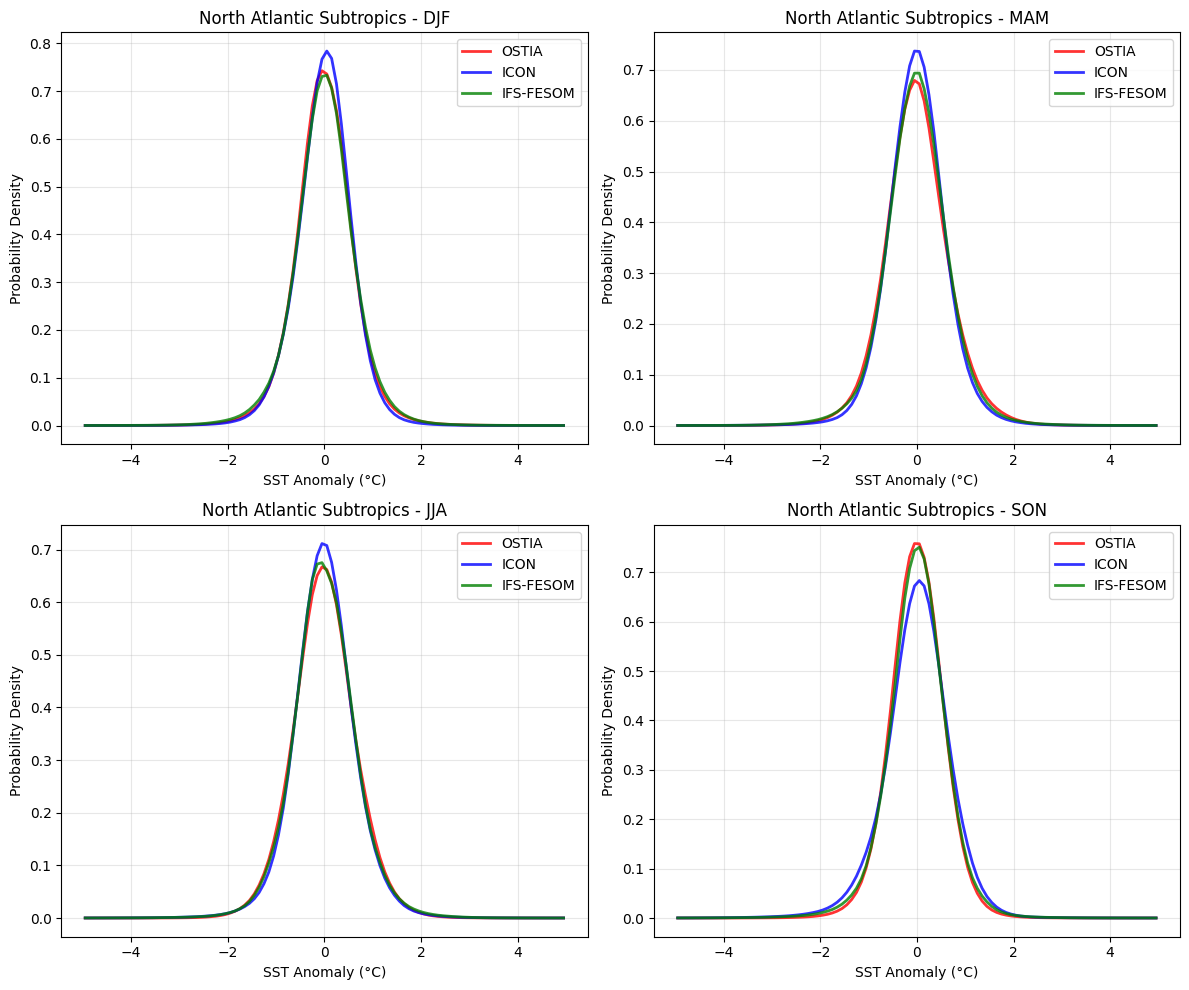


North Atlantic Subtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.612 |   70,346,510
ICON            |   -0.000 |    0.572 |   70,423,912
IFS-FESOM       |    0.000 |    0.645 |   70,403,073

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.671 |   71,740,680
ICON            |    0.000 |    0.614 |   71,819,616
IFS-FESOM       |    0.000 |    0.670 |   71,798,364

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.647 |   71,740,680
ICON            |   -0.000 |    0.643 |   71,819,616
IFS-FESOM       |   -0.000 |    0.668 |   71,798,364

SON Season:
Model           |     Mean |      Std |  Data Points
--------------------------

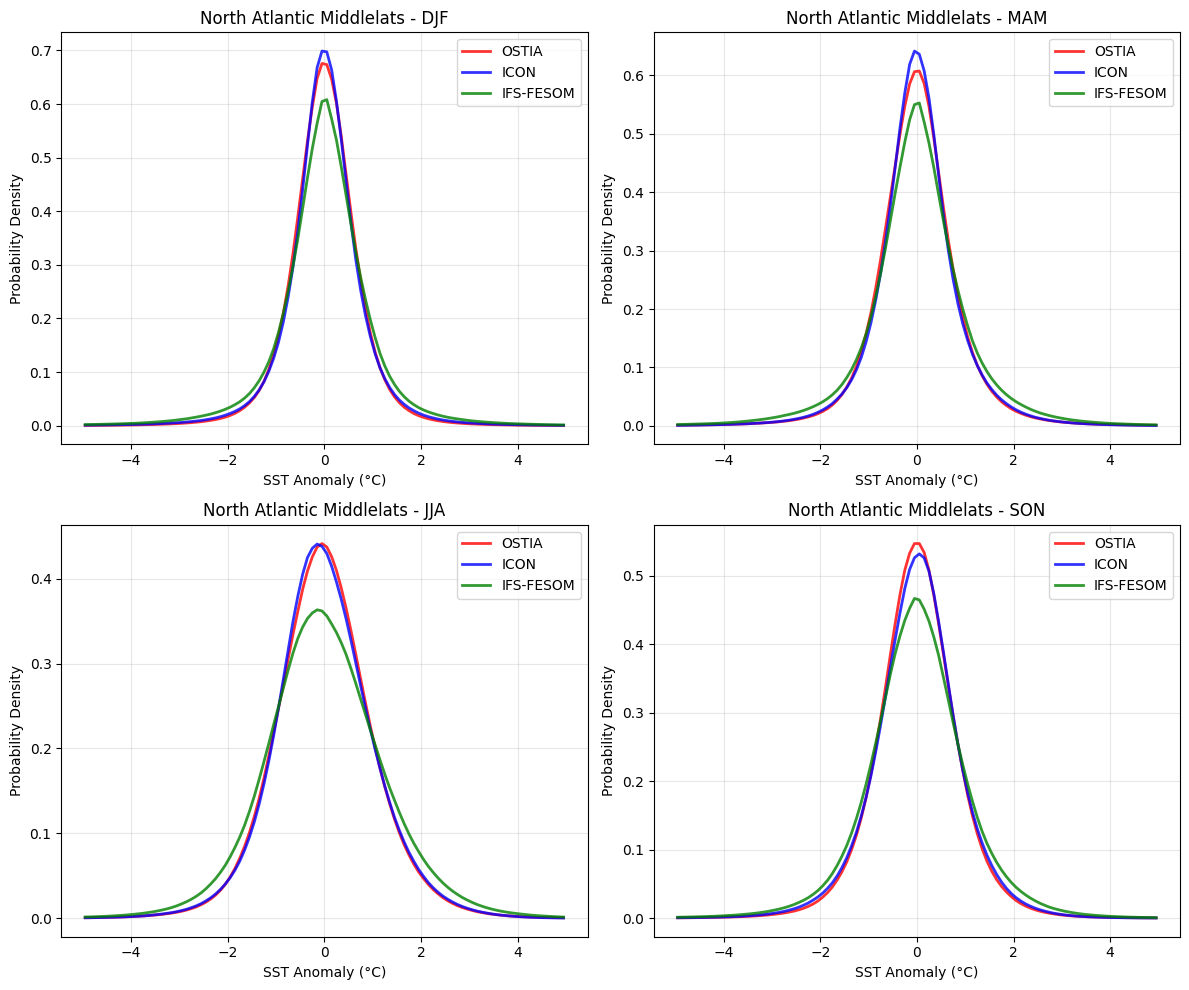


North Atlantic Middlelats - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.001 |    0.787 |  100,526,790
ICON            |    0.004 |    0.849 |  100,369,797
IFS-FESOM       |    0.003 |    1.092 |  100,341,362

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.003 |    0.912 |  101,991,078
ICON            |    0.006 |    0.890 |  102,202,064
IFS-FESOM       |    0.007 |    1.170 |  101,560,997

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.001 |    1.047 |  103,966,711
ICON            |    0.000 |    1.053 |  103,537,800
IFS-FESOM       |    0.000 |    1.275 |  103,421,005

SON Season:
Model           |     Mean |      Std |  Data Points
--------------------------

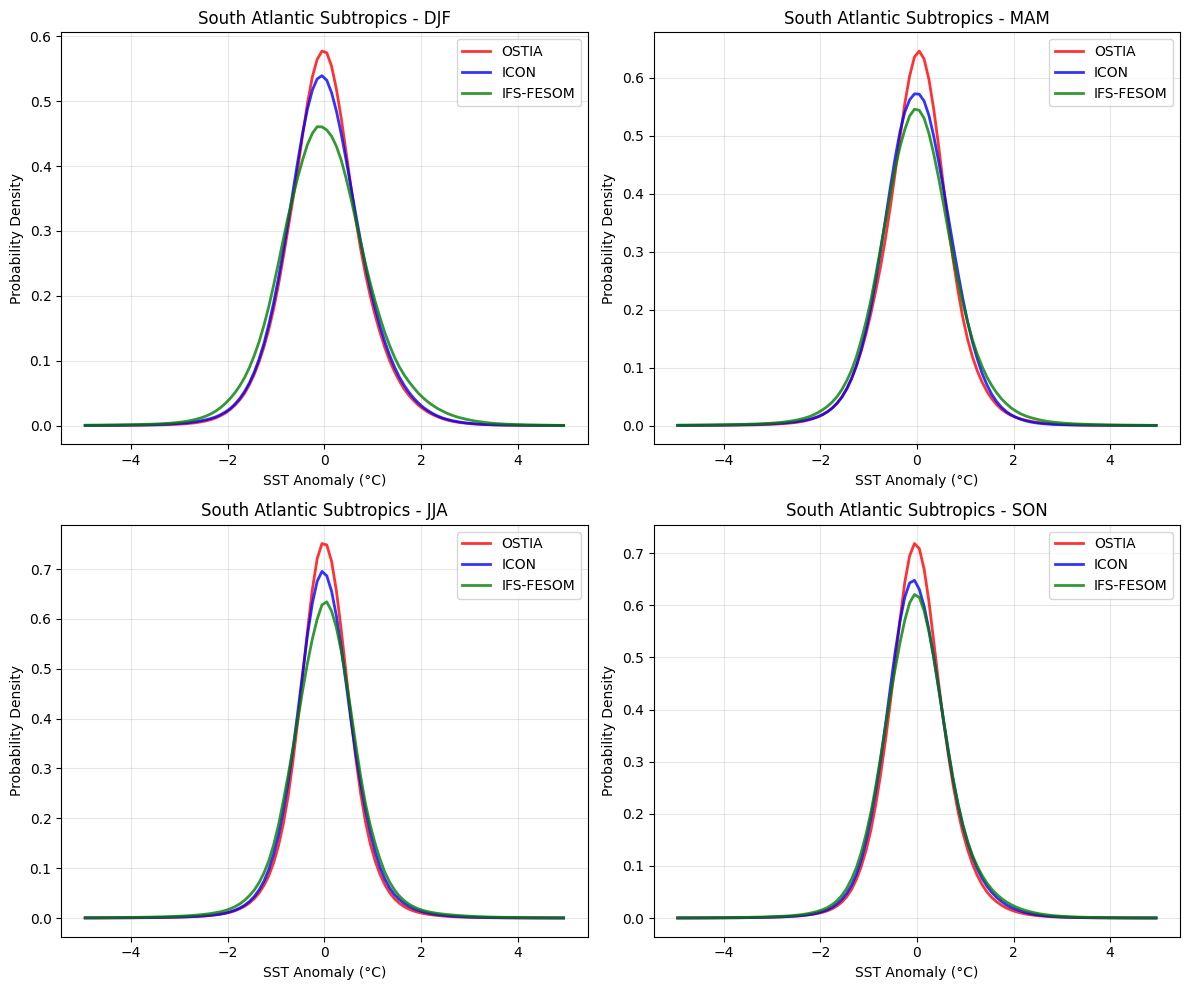


South Atlantic Subtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.810 |   88,976,576
ICON            |    0.000 |    0.858 |   88,187,671
IFS-FESOM       |   -0.000 |    0.986 |   88,181,717

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.740 |   90,739,968
ICON            |   -0.000 |    0.793 |   89,935,428
IFS-FESOM       |    0.000 |    0.882 |   89,929,356

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.655 |   90,739,968
ICON            |    0.000 |    0.700 |   89,935,428
IFS-FESOM       |    0.000 |    0.816 |   89,929,356

SON Season:
Model           |     Mean |      Std |  Data Points
--------------------------

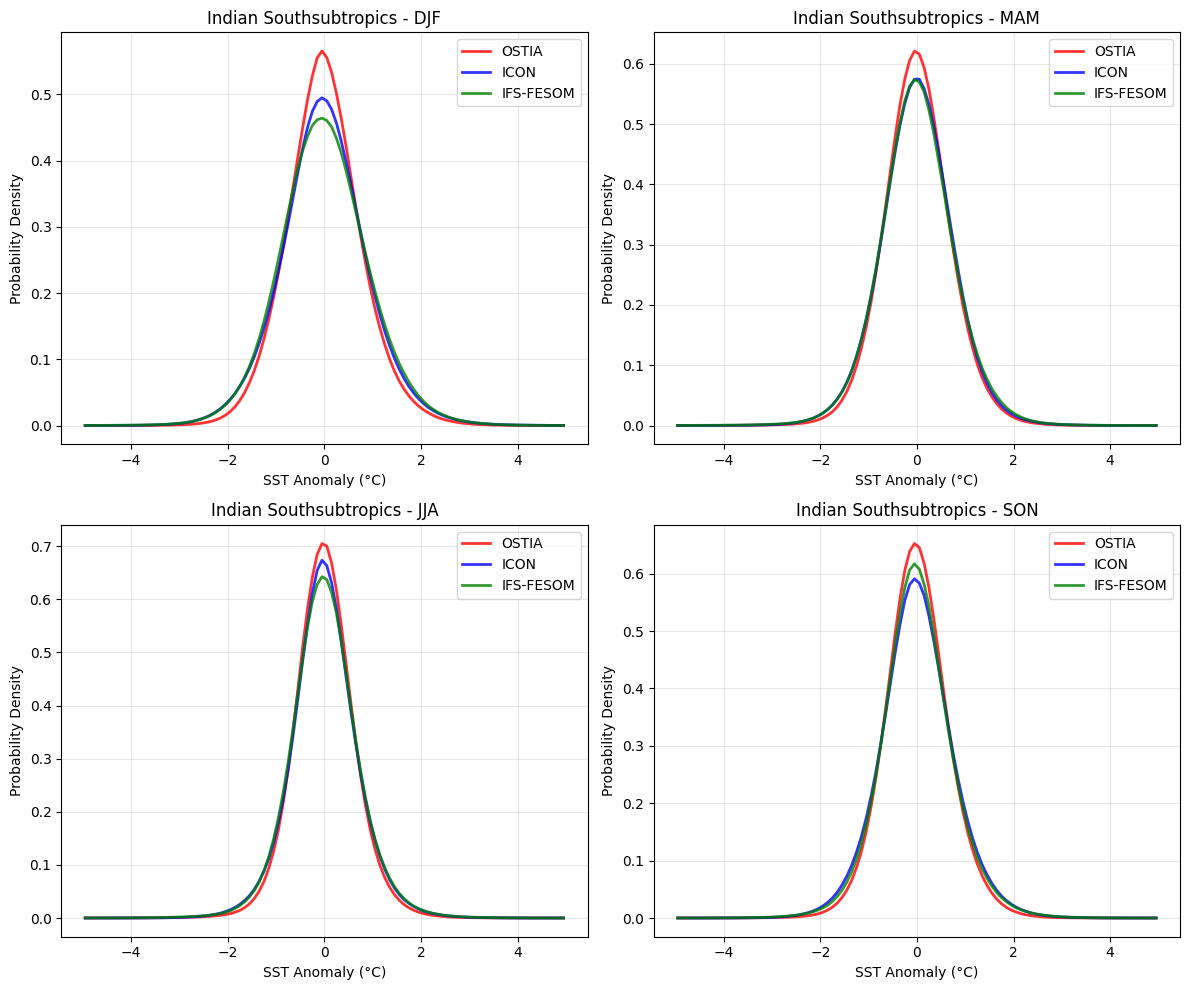


Indian Southsubtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.791 |  131,342,263
ICON            |    0.000 |    0.904 |  129,931,165
IFS-FESOM       |   -0.000 |    0.924 |  129,868,648

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.700 |  133,945,284
ICON            |   -0.000 |    0.755 |  132,506,220
IFS-FESOM       |    0.000 |    0.775 |  132,442,464

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.634 |  133,945,284
ICON            |   -0.000 |    0.693 |  132,506,220
IFS-FESOM       |   -0.000 |    0.712 |  132,442,464

SON Season:
Model           |     Mean |      Std |  Data Points
-----------------------------

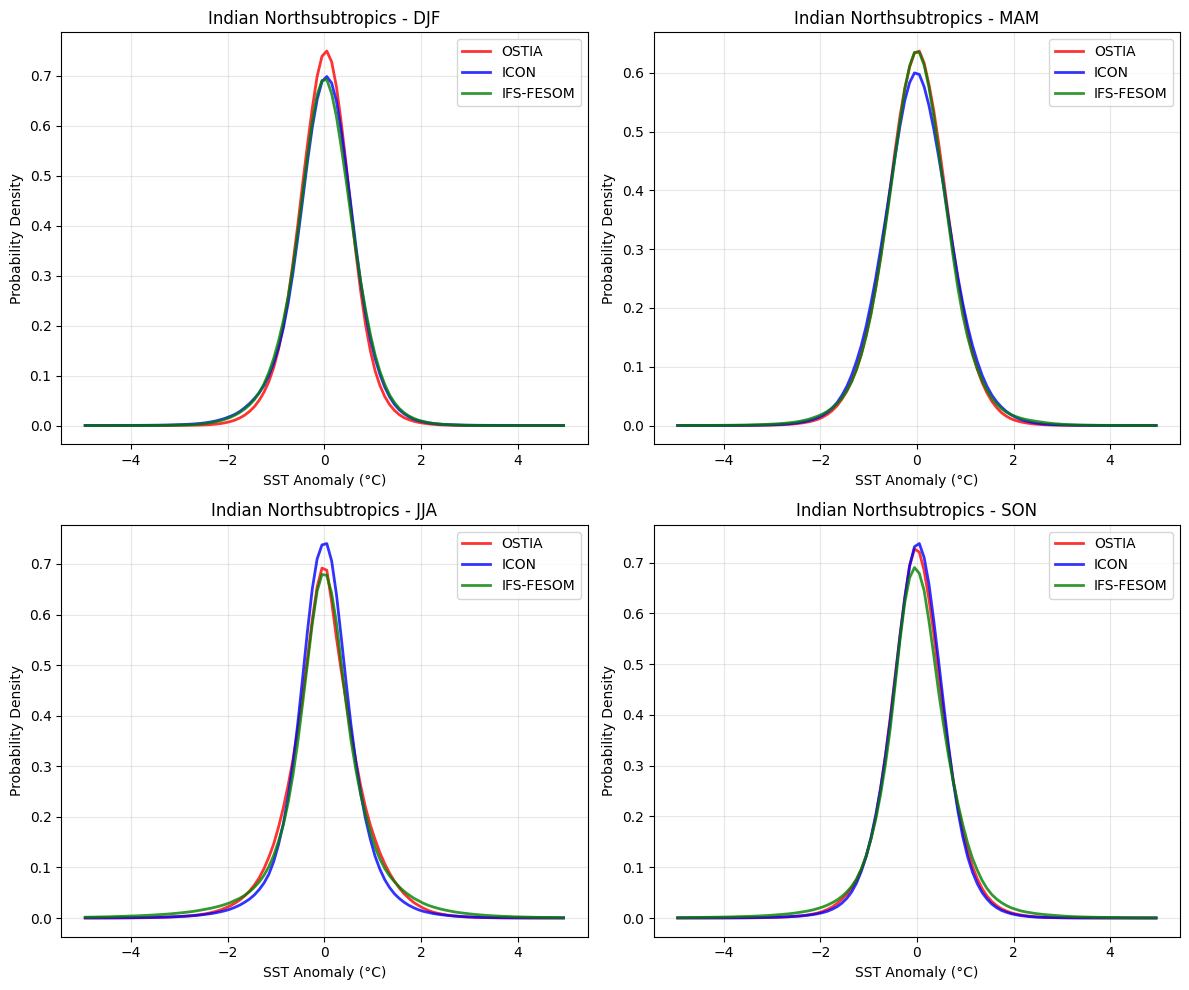


Indian Northsubtropics - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |   -0.000 |    0.587 |   24,566,204
ICON            |    0.000 |    0.666 |   24,325,067
IFS-FESOM       |    0.000 |    0.659 |   24,268,504

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.681 |   25,053,072
ICON            |    0.000 |    0.728 |   24,807,156
IFS-FESOM       |    0.000 |    0.737 |   24,749,472

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.756 |   25,053,072
ICON            |   -0.000 |    0.695 |   24,807,156
IFS-FESOM       |   -0.000 |    0.961 |   24,749,472

SON Season:
Model           |     Mean |      Std |  Data Points
-----------------------------

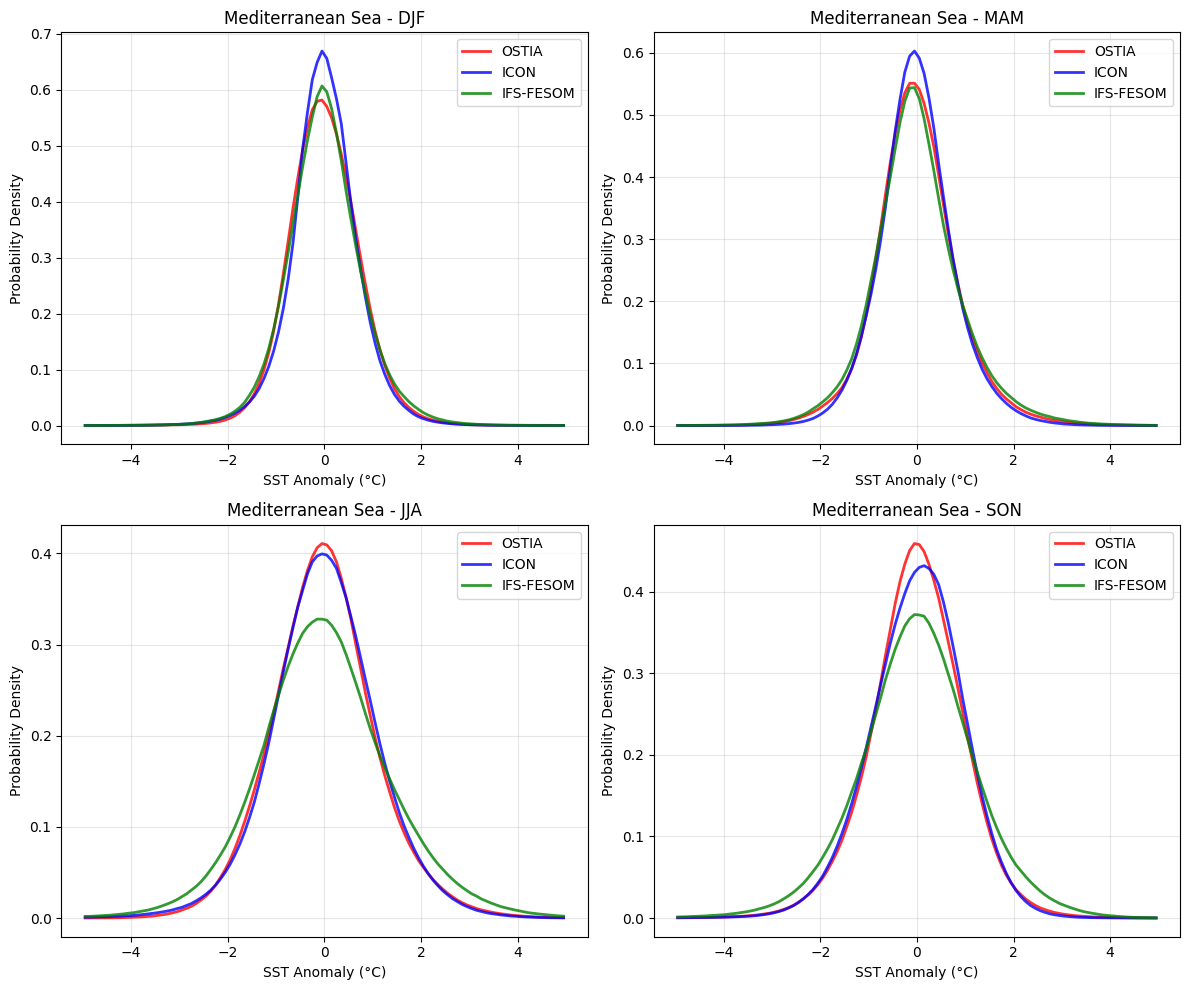


Mediterranean Sea - SEASONAL STATISTICS:

DJF Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.001 |    0.741 |   14,568,580
ICON            |   -0.000 |    0.706 |   14,661,725
IFS-FESOM       |    0.001 |    0.786 |   14,414,634

MAM Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.000 |    0.865 |   14,868,369
ICON            |    0.000 |    0.773 |   14,952,300
IFS-FESOM       |   -0.000 |    0.937 |   14,700,312

JJA Season:
Model           |     Mean |      Std |  Data Points
------------------------------------------------------------
OSTIA           |    0.001 |    1.087 |   14,873,364
ICON            |   -0.000 |    1.115 |   14,952,300
IFS-FESOM       |    0.001 |    1.390 |   14,700,312

SON Season:
Model           |     Mean |      Std |  Data Points
----------------------------------

In [7]:

# Or analyse specific regions only
#specific_regions = ['North_Pacific_SubTropics', 'Southern_Ocean', 'North_Atlantic_MiddleLats']
regional_seasonal_pdfs, masks = quick_regional_seasonal_analysis(
    models_dict
)